In [1]:
import os
import time
import pandas as pd
import numpy as np
import warnings
import joblib

# Suppress warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import ParameterSampler, TimeSeriesSplit, cross_val_score
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import AdaBoostClassifier
from sklearn.metrics         import (classification_report, confusion_matrix, 
                                     f1_score, precision_score, recall_score, 
                                     roc_auc_score, average_precision_score, 
                                     precision_recall_curve, accuracy_score)

# ============================================================
# SETUP DIRECTORIES
# ============================================================
SAVE_DIR = '/kaggle/working/adaboost_results/'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Save directory : {SAVE_DIR}\n")

# ============================================================
print("============================================================")
print("BLOCK 1: LOADING DATASET")
print("============================================================")
start_time = time.time()
df = pd.read_csv('/kaggle/input/datasets/rithishwars/ml-final-dataset/Final_Topology_Dataset_FULL_0_to_5__2.csv')
df = df.sort_values('time_window').reset_index(drop=True)

# Impute with -9999. Tree models handle extreme values better than 0.
X = df.drop(columns=['um','dm','time_window','violation_next_window']).replace([np.inf,-np.inf],np.nan).fillna(-9999)
y = df['violation_next_window']

load_time = time.time() - start_time
print(f"  Loaded in      : {load_time:.1f}s")
print(f"  Total samples  : {len(X):,}")
print(f"  Violation rate : {(y.sum()/len(X))*100:.2f}%")
print(f"  Normal         : {len(X) - y.sum():,}")
print(f"  Violated       : {y.sum():,}\n")

# ============================================================
print("============================================================")
print("BLOCK 2: TEMPORAL SPLIT (80/15/5)")
print("============================================================")
n = len(X)
split1 = int(n * 0.95)
split2 = int(split1 * 0.80)

# Using raw X, y (Scaling removed as it's not required for trees)
X_train, y_train = X.iloc[:split2], y.iloc[:split2]
X_test,  y_test  = X.iloc[split2:split1], y.iloc[split2:split1]
X_unseen, y_unseen = X.iloc[split1:], y.iloc[split1:]

print(f"  Train  : {len(X_train):,} | Violations: {y_train.sum():,} ({(y_train.sum()/len(X_train))*100:.2f}%)")
print(f"  Test   : {len(X_test):,} | Violations: {y_test.sum():,} ({(y_test.sum()/len(X_test))*100:.2f}%)")
print(f"  Unseen : {len(X_unseen):,} | Violations: {y_unseen.sum():,} ({(y_unseen.sum()/len(X_unseen))*100:.2f}%)\n")

# ============================================================
print("============================================================")
print("BLOCK 3: CLASS IMBALANCE STRATEGY")
print("============================================================")
print("  Strategy : Balanced Base Estimator + SAMME Algorithm")
print("             Directly learning from raw topological metrics.\n")

# ============================================================
print("============================================================")
print("BLOCK 4: RANDOMIZED HYPERPARAMETER SEARCH — 10 TRIALS")
print("============================================================")
print("-" * 60)

param_grid = {
    'n_estimators'  : [50, 100, 200, 300],
    'learning_rate' : [0.01, 0.05, 0.1, 0.3],
    'max_depth'     : [1, 2, 3]
}

N_TRIALS = 10
param_list = list(ParameterSampler(param_grid, n_iter=N_TRIALS, random_state=42))
tscv = TimeSeriesSplit(n_splits=3)

trial_results = []
best_score = -1
best_params = None

for i, params in enumerate(param_list):
    trial_start = time.time()
    
    # Injecting class_weight='balanced' into the weak learner
    base = DecisionTreeClassifier(max_depth=params['max_depth'], class_weight='balanced', random_state=42)
    
    # Removed the deprecated 'algorithm' parameter
    ada = AdaBoostClassifier(estimator=base, 
                             n_estimators=params['n_estimators'], 
                             learning_rate=params['learning_rate'],
                             random_state=42)
    
    scores = cross_val_score(ada, X_train, y_train, cv=tscv, scoring='f1', n_jobs=-1)
    mean_f1 = scores.mean()
    trial_time = time.time() - trial_start
    
    print(f"  Trial {i+1:02d}/{N_TRIALS:02d} | est={params['n_estimators']} | lr={params['learning_rate']} | depth={params['max_depth']}")
    print(f"  Val F1: {mean_f1:.4f} | Time: {trial_time:.1f}s\n")
    
    trial_results.append({
        'trial': i+1, 'estimators': params['n_estimators'], 
        'lr': params['learning_rate'], 'depth': params['max_depth'],
        'val_f1': mean_f1, 'time_s': trial_time
    })
    
    if mean_f1 > best_score:
        best_score = mean_f1
        best_params = params

print("SEARCH COMPLETE")
print(f"  Best Val F1 : {best_score:.4f}")
print("============================================================\n")

# ============================================================
print("============================================================")
print("BLOCK 5: RETRAINING BEST MODEL")
print("============================================================")
final_base = DecisionTreeClassifier(max_depth=best_params['max_depth'], class_weight='balanced', random_state=42)

# Removed the deprecated 'algorithm' parameter
final_ada = AdaBoostClassifier(estimator=final_base, 
                               n_estimators=best_params['n_estimators'], 
                               learning_rate=best_params['learning_rate'],
                               random_state=42)

fit_start = time.time()
final_ada.fit(X_train, y_train)
joblib.dump(final_ada, f"{SAVE_DIR}adaboost_best_model.pkl")

print(f"  Model trained on full train set in {time.time()-fit_start:.2f}s")
print(f"  adaboost_best_model.pkl : Saved\n")

# ============================================================
print("============================================================")
print("BLOCK 6: THRESHOLD OPTIMIZATION")
print("============================================================")
y_prob_test   = final_ada.predict_proba(X_test)[:, 1]
pre, rec, thr = precision_recall_curve(y_test, y_prob_test)
f1_thr        = 2*pre*rec / (pre+rec+1e-9)
best_thr      = thr[np.argmax(f1_thr[:-1])]

print(f"  Optimal threshold (F1) : {best_thr:.4f}\n")

# ============================================================
print("============================================================")
print("BLOCK 7: FINAL EVALUATION (UNSEEN VAULT)")
print("============================================================")
y_prob_unseen = final_ada.predict_proba(X_unseen)[:, 1]
y_pred_unseen = (y_prob_unseen >= best_thr).astype(int)

auprc = average_precision_score(y_unseen, y_prob_unseen)
f1    = f1_score(y_unseen, y_pred_unseen, zero_division=0)
rec   = recall_score(y_unseen, y_pred_unseen, zero_division=0)
prec  = precision_score(y_unseen, y_pred_unseen, zero_division=0)

print(f"  AUPRC               : {auprc:.4f}")
print(f"  F1 Score            : {f1:.4f}")
print(f"  Precision           : {prec:.4f}")
print(f"  Recall (Catch Rate) : {rec:.4f}\n")
print("  Classification Report:")
print(classification_report(y_unseen, y_pred_unseen, target_names=['Normal','Violation']))

# ============================================================
print("============================================================")
print("BLOCK 8: FINAL SUMMARY")
print("============================================================")
print(f"  SAVE DIRECTORY : {SAVE_DIR}")
print(f"  Test AUPRC     : {auprc:.4f}")
print(f"  Test Recall    : {rec:.4f}")
print(f"  Opt Threshold  : {best_thr:.4f}")
print("\nALL BLOCKS COMPLETE.")
print("============================================================")

Save directory : /kaggle/working/adaboost_results/

BLOCK 1: LOADING DATASET
  Loaded in      : 2.4s
  Total samples  : 178,930
  Violation rate : 5.13%
  Normal         : 169,752
  Violated       : 9,178

BLOCK 2: TEMPORAL SPLIT (80/15/5)
  Train  : 135,986 | Violations: 6,916 (5.09%)
  Test   : 33,997 | Violations: 1,762 (5.18%)
  Unseen : 8,947 | Violations: 500 (5.59%)

BLOCK 3: CLASS IMBALANCE STRATEGY
  Strategy : Balanced Base Estimator + SAMME Algorithm
             Directly learning from raw topological metrics.

BLOCK 4: RANDOMIZED HYPERPARAMETER SEARCH — 10 TRIALS
------------------------------------------------------------
  Trial 01/10 | est=300 | lr=0.1 | depth=1
  Val F1: 0.5983 | Time: 12.4s

  Trial 02/10 | est=50 | lr=0.3 | depth=2
  Val F1: 0.5173 | Time: 4.3s

  Trial 03/10 | est=200 | lr=0.1 | depth=1
  Val F1: 0.5983 | Time: 9.7s

  Trial 04/10 | est=300 | lr=0.3 | depth=2
  Val F1: 0.5173 | Time: 4.6s

  Trial 05/10 | est=50 | lr=0.1 | depth=1
  Val F1: 0.5983 | 

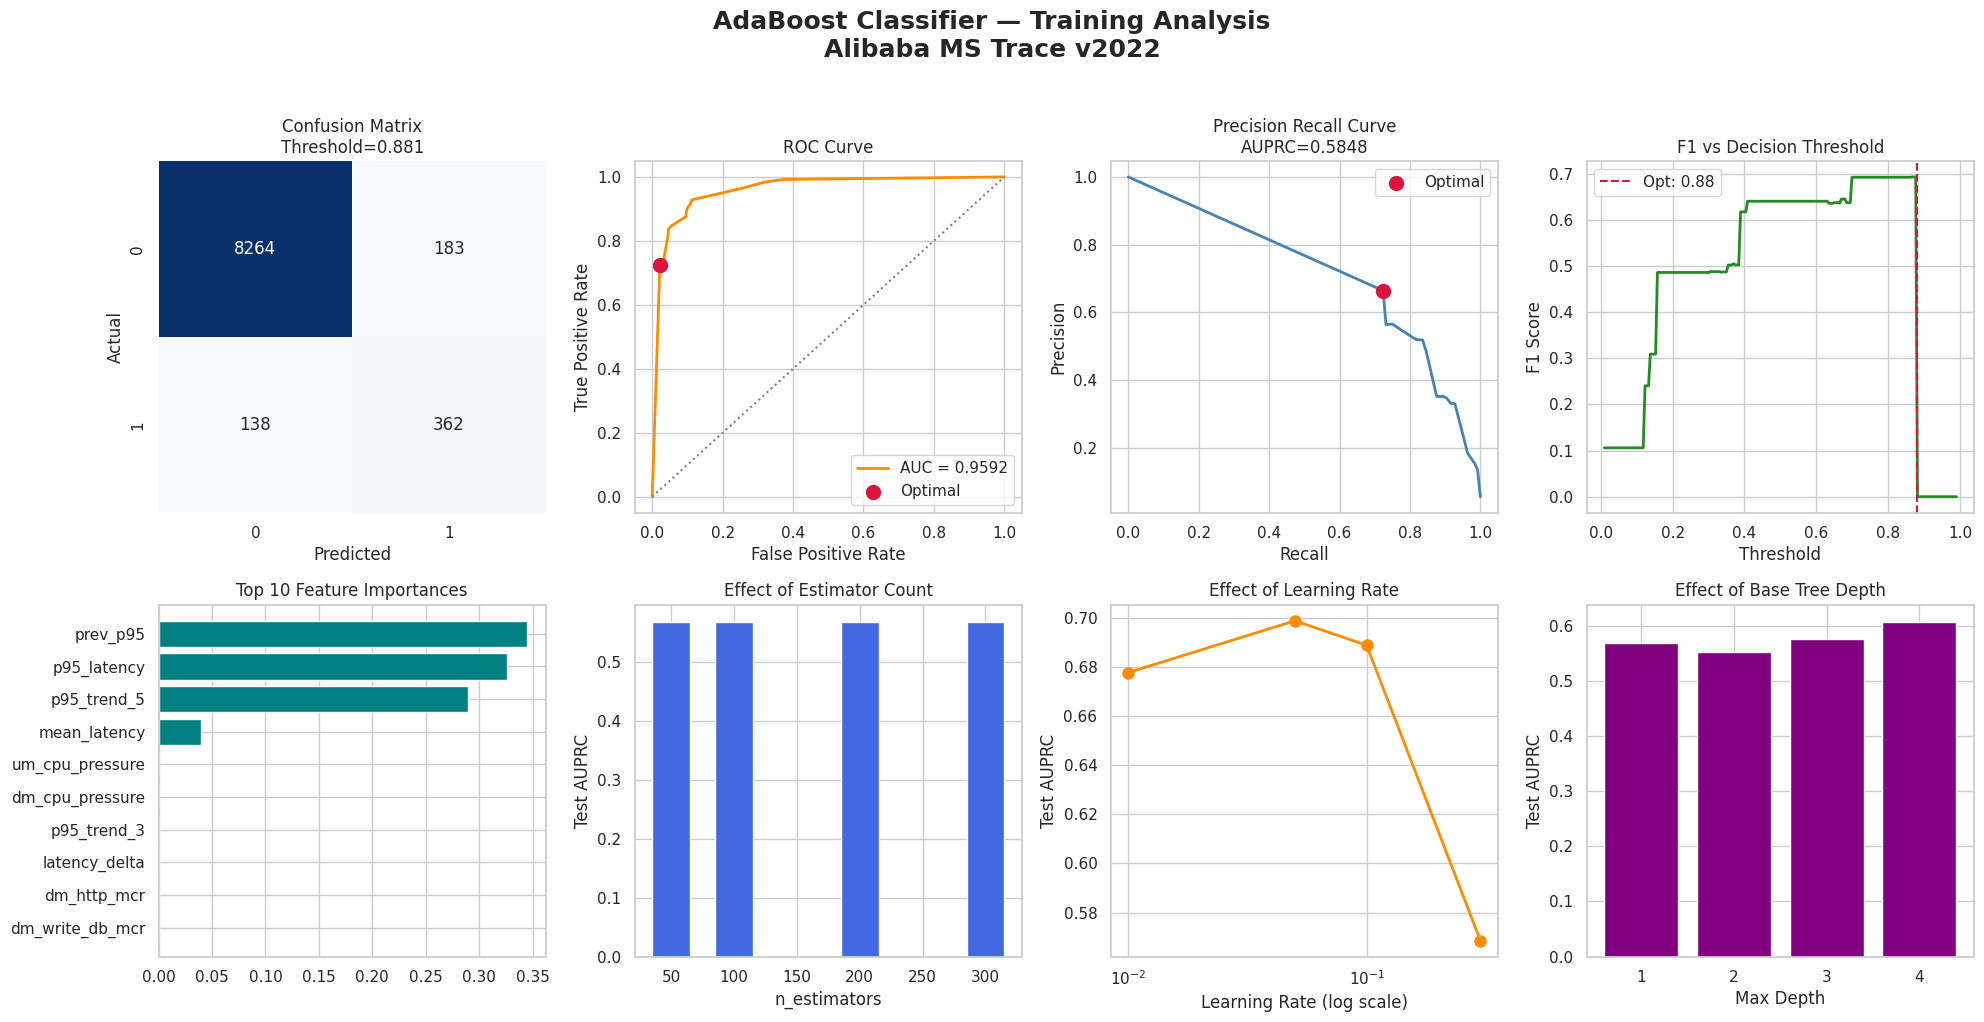

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (confusion_matrix, precision_recall_curve, 
                             average_precision_score, roc_curve, auc, 
                             f1_score)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

sns.set_theme(style="whitegrid")

# ======================================================
# Generate predictions (Requires training cell to be run first!)
# ======================================================
y_prob = final_ada.predict_proba(X_unseen)[:,1]
y_pred = (y_prob >= best_thr).astype(int)

# ======================================================
# Math Preparations
# ======================================================
# PR Math
precision, recall, thresholds = precision_recall_curve(y_unseen, y_prob)
auprc = average_precision_score(y_unseen, y_prob)

# ROC Math
fpr, tpr, roc_thresholds = roc_curve(y_unseen, y_prob)
roc_auc = auc(fpr, tpr)

# F1 vs Threshold Math
f1_scores = []
thr_range = np.linspace(0.01, 0.99, 200)
for t in thr_range:
    preds = (y_prob >= t).astype(int)
    f1_scores.append(f1_score(y_unseen, preds, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_unseen, y_pred)

# ======================================================
# Plot Dashboard (2x4 Grid)
# ======================================================
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# ------------------------------------------------------
# 1. Confusion Matrix
# ------------------------------------------------------
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0,0], cbar=False)
axes[0,0].set_title(f"Confusion Matrix\nThreshold={best_thr:.3f}")
axes[0,0].set_xlabel("Predicted")
axes[0,0].set_ylabel("Actual")

# ------------------------------------------------------
# 2. ROC Curve 
# ------------------------------------------------------
axes[0,1].plot(fpr, tpr, color='darkorange', linewidth=2, label=f"AUC = {roc_auc:.4f}")
axes[0,1].plot([0,1], [0,1], color='gray', linestyle=':')

opt_idx_roc = (np.abs(roc_thresholds - best_thr)).argmin()
axes[0,1].scatter(
    fpr[opt_idx_roc], tpr[opt_idx_roc], 
    color='crimson', s=100, label="Optimal", zorder=5
)

axes[0,1].set_title("ROC Curve")
axes[0,1].set_xlabel("False Positive Rate")
axes[0,1].set_ylabel("True Positive Rate")
axes[0,1].legend()

# ------------------------------------------------------
# 3. Precision Recall Curve
# ------------------------------------------------------
axes[0,2].plot(recall, precision, color='steelblue', linewidth=2)

opt_idx_pr = (np.abs(thresholds - best_thr)).argmin()
axes[0,2].scatter(
    recall[opt_idx_pr], precision[opt_idx_pr], 
    color='crimson', s=100, label="Optimal", zorder=5
)

axes[0,2].set_title(f"Precision Recall Curve\nAUPRC={auprc:.4f}")
axes[0,2].set_xlabel("Recall")
axes[0,2].set_ylabel("Precision")
axes[0,2].legend()

# ------------------------------------------------------
# 4. F1 vs Threshold
# ------------------------------------------------------
axes[0,3].plot(thr_range, f1_scores, color='forestgreen', linewidth=2)
axes[0,3].axvline(best_thr, color='crimson', linestyle='--', label=f"Opt: {best_thr:.2f}")
axes[0,3].set_title("F1 vs Decision Threshold")
axes[0,3].set_xlabel("Threshold")
axes[0,3].set_ylabel("F1 Score")
axes[0,3].legend()

# ------------------------------------------------------
# 5. Feature Importance
# ------------------------------------------------------
importances = final_ada.feature_importances_
idx = np.argsort(importances)[-10:]

axes[1,0].barh(np.array(X.columns)[idx], importances[idx], color='teal')
axes[1,0].set_title("Top 10 Feature Importances")

# ------------------------------------------------------
# 6. Estimator Effect
# ------------------------------------------------------
est_vals = [50, 100, 200, 300]
scores_est = []

for e in est_vals:
    model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=best_params['max_depth'], class_weight='balanced', random_state=42),
        n_estimators=e, learning_rate=best_params['learning_rate'], random_state=42
    )
    model.fit(X_train, y_train)
    scores_est.append(average_precision_score(y_test, model.predict_proba(X_test)[:,1]))

axes[1,1].bar(est_vals, scores_est, width=30, color='royalblue')
axes[1,1].set_title("Effect of Estimator Count")
axes[1,1].set_xlabel("n_estimators")
axes[1,1].set_ylabel("Test AUPRC")

# ------------------------------------------------------
# 7. Learning Rate Effect 
# ------------------------------------------------------
lr_vals = [0.01, 0.05, 0.1, 0.3]
scores_lr = []

for lr in lr_vals:
    model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=best_params['max_depth'], class_weight='balanced', random_state=42),
        n_estimators=best_params['n_estimators'], learning_rate=lr, random_state=42
    )
    model.fit(X_train, y_train)
    scores_lr.append(average_precision_score(y_test, model.predict_proba(X_test)[:,1]))

axes[1,2].plot(lr_vals, scores_lr, marker='o', markersize=8, color='darkorange', linewidth=2)
axes[1,2].set_xscale("log")
axes[1,2].set_title("Effect of Learning Rate")
axes[1,2].set_xlabel("Learning Rate (log scale)")
axes[1,2].set_ylabel("Test AUPRC")

# ------------------------------------------------------
# 8. Tree Depth Effect 
# ------------------------------------------------------
depth_vals = [1, 2, 3, 4]
scores_depth = []

for d in depth_vals:
    model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=d, class_weight='balanced', random_state=42),
        n_estimators=best_params['n_estimators'], learning_rate=best_params['learning_rate'], random_state=42
    )
    model.fit(X_train, y_train)
    scores_depth.append(average_precision_score(y_test, model.predict_proba(X_test)[:,1]))

axes[1,3].bar(depth_vals, scores_depth, color='purple')
axes[1,3].set_title("Effect of Base Tree Depth")
axes[1,3].set_xlabel("Max Depth")
axes[1,3].set_ylabel("Test AUPRC")
axes[1,3].set_xticks([1, 2, 3, 4])

# ------------------------------------------------------
plt.suptitle("AdaBoost Classifier — Training Analysis\nAlibaba MS Trace v2022", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()

plt.savefig(f"{SAVE_DIR}adaboost_dashboard.png", dpi=200, bbox_inches='tight')
plt.show()